In [1]:
import warnings

import matplotlib.pyplot as plt
import nivapy3 as nivapy
import numpy as np
import pandas as pd
import seaborn as sn
import lillestrom_utils as utils

warnings.simplefilter("ignore")
plt.style.use("ggplot")

In [2]:
COLOUR_DICT = {
    # "Akvakultur": "royalblue",
    "Jordbruk": "sienna",
    "Avløp": "red",
    "Industri": "darkgrey",
    "Bebygd": "gold",
    "Bakgrunn": "limegreen",
}
# COLOUR_DICT = {
#     "Akvakultur": "royalblue",
#     "Jordbruk": "sienna",
#     "Avløp": "red",
#     "Spredt": "black",
#     "Overflow": "blue",
#     "Industri": "darkgrey",
#     "Bebygd": "gold",
#     "Bakgrunn": "limegreen",
# }

# TEOTIL3 for Lillestrøm kommune
# Notebook 07a: Comparision with TEOTIL for monitoring stations

This notebook compares results from TEOTIL3 to measured loads at specific **monitoring stations** (calculated in notebook 4a).

## 1. Sites of interest

**Note:** Sagelva, Nitelva and Leira are all reasonably large catchments comprising several regine units. This makes them suitable for modelling using TEOTIL3. Rømua and Åa are both single regine catchments, which is not ideal for TEOTIL3. Rømua is larger than Åa, so I would expect results for Rømua to be better than for Åa, but neither is really suitable for modelling using TEOTIL3. Jeksla and Gansåa are both small and cover less than one regine, so these are not suitable for modelling with TEOTIL3.

In [3]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df = stn_df[stn_df["comment"].str.startswith("Downstream")]

stn_df

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream
11,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,002-3655-R,Gansåa,11.22275,59.86139,Downstream. Small part of regine


## 2. Read TEOTIL3 data

In [4]:
# TEOTIL options
st_yr = 2013
end_yr = 2024
nve_data_yr = 2025
agri_loss_model = "annual"
pars = ["TOTN", "TOTP", "TOC", "SS"]

In [5]:
# Aggregate data
teo_df = utils.get_teotil3_results(
    st_yr,
    end_yr,
    stn_df["regine"].tolist(),
    agri_loss_model,
    nve_data_yr,
)
id_cols = ["regine", "Parameter", "År"]
df_list = []
for par in pars:
    par_df = utils.aggregate_parameters(teo_df, par.lower())
    par_df["Parameter"] = par
    val_cols = [col for col in par_df.columns if col not in id_cols]
    par_df = par_df[id_cols + val_cols].sort_values(id_cols)
    df_list.append(par_df)

# Merge
mod_df = pd.concat(df_list, axis="rows")
mod_df = pd.merge(
    stn_df[["catchment", "station_id", "station_name", "regine"]],
    mod_df,
    how="right",
    on="regine",
)
mod_df["Akvakultur"] = mod_df["Akvakultur"].fillna(0)
mod_df.head()

,catchment,station_id,station_name,regine,Parameter,År,Jordbruk,Avløp,Industri,Bebygd,Bakgrunn,Akvakultur
0,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2013,6227.215668,1589.914108,26.550678,323.213056,4542.862273,0.0
1,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2014,6762.113380,1563.572930,27.342585,383.069527,5261.994068,0.0
2,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2015,5201.268168,1689.192216,26.927294,352.463377,4744.826651,0.0
3,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2016,5455.828630,1774.816045,33.869105,279.301439,3956.406236,0.0
4,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2017,5407.416408,1733.178313,30.106311,320.746379,4407.446858,0.0


## 3. Read observed loads for stations

From Notebook 04a.

In [6]:
xl_path = r"../data/annual_loads_stations.xlsx"
obs_df = pd.read_excel(xl_path, sheet_name="annual_loads")
obs_df.head()

,station_code,year,TOTN_tonn,TOTP_tonn,SS_tonn,TOC_tonn
0,002-28960,1990,96.300590,3.134720,1125.209562,374.573984
1,002-28960,1991,188.748221,8.012179,3578.643200,520.207794
2,002-28960,1992,170.753689,5.391133,3016.063269,459.973911
3,002-28960,1998,232.150551,8.431335,3146.030529,662.295678
4,002-28960,1999,234.147542,24.474299,19898.397088,NaN


## 4. Compare modelled to observed

In [7]:
cat_df = pd.read_excel(r"../data/vannmiljo_catch_metadata.xlsx")

val_cols = ["Jordbruk", "Avløp", "Industri", "Bebygd", "Bakgrunn"]
# val_cols = ["Jordbruk", "Avløp", "Spredt", "Overflow", "Industri", "Bebygd", "Bakgrunn"]
for idx, row in stn_df.iterrows():
    # Get modelled and observed data for station
    stn_id = row["station_id"]
    reg_id = row["regine"]
    name = row["catchment"]
    mod_stn_df = mod_df.query("station_id == @stn_id").copy()
    obs_stn_df = obs_df.query("(station_code == @stn_id) and (year >= 2013)").copy()

    # Scale to allow for regine outflows not exactly matching monitoring sites
    obs_area = cat_df.query("station_code == @stn_id")["cat_area_km2"].iloc[0]
    mod_area = teo_df.query("regine == @reg_id")["accum_upstr_area_km2"].iloc[0]
    mod_stn_df[val_cols] = mod_stn_df[val_cols] * obs_area / mod_area

    # Plot
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
    axes = axes.flatten()
    handles, labels = None, None
    for ax_idx, par in enumerate(pars):
        ax = axes[ax_idx]
        mod_par_df = (
            mod_stn_df.query("Parameter == @par")[["År"] + val_cols]
            .sort_values("År")
            .set_index("År")
        )
        obs_par_df = (
            obs_stn_df[["year", f"{par}_tonn"]]
            .dropna(subset=f"{par}_tonn")
            .sort_values("year")
            .set_index("year")
        )

        # Stacked bar chart for modelled
        bottom = None
        for col in val_cols:
            values = mod_par_df[col]
            if bottom is None:
                ax.bar(
                    mod_par_df.index,
                    values,
                    label=col,
                    color=COLOUR_DICT[col],
                )
                bottom = values.copy()
            else:
                ax.bar(
                    mod_par_df.index,
                    values,
                    bottom=bottom,
                    label=col,
                    color=COLOUR_DICT[col],
                )
                bottom += values

        # Line chart for observed
        ax.plot(
            obs_par_df.index,
            obs_par_df[f"{par}_tonn"],
            color="k",
            marker="o",
            linestyle="-",
            label="Observert",
            linewidth=2,
        )

        ax.set_title(par)
        ax.set_ylabel("Tilførsler (tonn)")
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    # Legend
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
    )

    # fig.suptitle(f"{name} ({stn_id})")
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Save
    png_path = f"../plots/modelled/mod_vs_obs_{name}_station_{stn_id}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")

    plt.close()

## 5. Source apportionment

In [8]:
# Period for percentage contributions
src_st_yr = 2020
src_end_yr = 2024

# Whether to separate spredt and overflows or keep them with avløp
inc_sp_ov = False

In [9]:
# Aggregate TEO3 data
teo_df = utils.get_teotil3_results(
    st_yr,
    end_yr,
    stn_df["regine"].tolist(),
    agri_loss_model,
    nve_data_yr,
)
id_cols = ["regine", "Parameter", "År"]
df_list = []
for par in pars:
    if inc_sp_ov:
        agg_dict = {
            "Jordbruk": [f"accum_agriculture_{par.lower()}_tonnes"],
            "Avløp": [f"accum_large-wastewater_{par.lower()}_tonnes"],
            "Spredt": [f"accum_spredt_{par.lower()}_tonnes"],
            "Overflow": [f"accum_overflow_{par.lower()}_tonnes"],
            "Industri": [f"accum_industry_{par.lower()}_tonnes"],
            "Bebygd": [f"accum_urban_{par.lower()}_tonnes"],
            "Bakgrunn": [
                f"accum_agriculture-background_{par.lower()}_tonnes",
                f"accum_upland_{par.lower()}_tonnes",
                f"accum_wood_{par.lower()}_tonnes",
            ],
        }
    else:
        agg_dict = None
    par_df = utils.aggregate_parameters(teo_df, par.lower(), agg_dict=agg_dict)
    par_df["Parameter"] = par
    val_cols = [col for col in par_df.columns if col not in id_cols]
    par_df = par_df[id_cols + val_cols].sort_values(id_cols)
    df_list.append(par_df)

# Merge
mod_df = pd.concat(df_list, axis="rows")
mod_df = pd.merge(
    stn_df[["catchment", "station_id", "station_name", "regine"]],
    mod_df,
    how="right",
    on="regine",
)
mod_df["Akvakultur"] = mod_df["Akvakultur"].fillna(0)

mod_df.head()

,catchment,station_id,station_name,regine,Parameter,År,Jordbruk,Avløp,Industri,Bebygd,Bakgrunn,Akvakultur
0,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2013,6227.215668,1589.914108,26.550678,323.213056,4542.862273,0.0
1,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2014,6762.113380,1563.572930,27.342585,383.069527,5261.994068,0.0
2,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2015,5201.268168,1689.192216,26.927294,352.463377,4744.826651,0.0
3,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2016,5455.828630,1774.816045,33.869105,279.301439,3956.406236,0.0
4,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,TOTN,2017,5407.416408,1733.178313,30.106311,320.746379,4407.446858,0.0


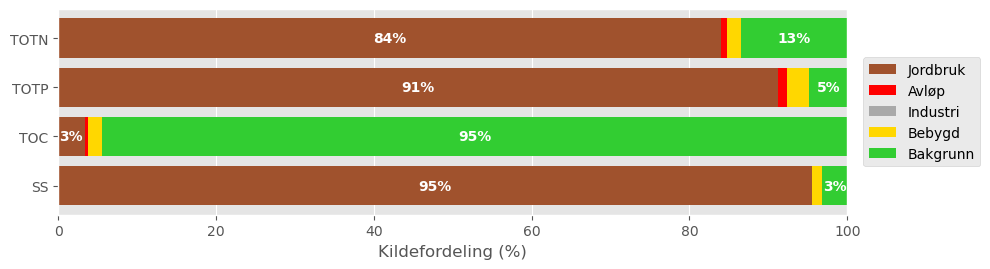

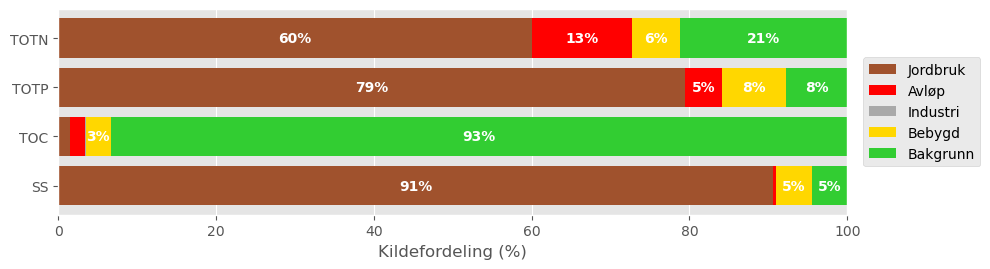

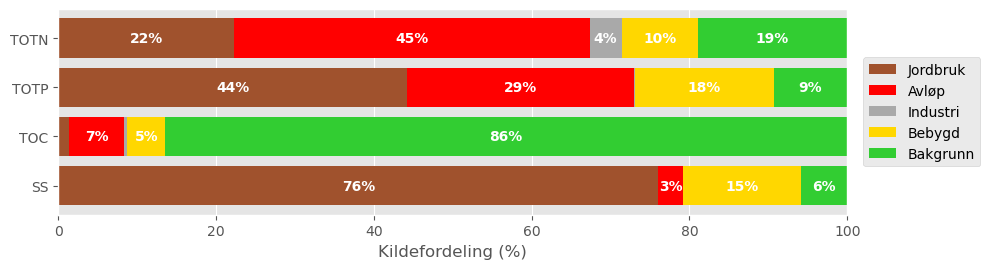

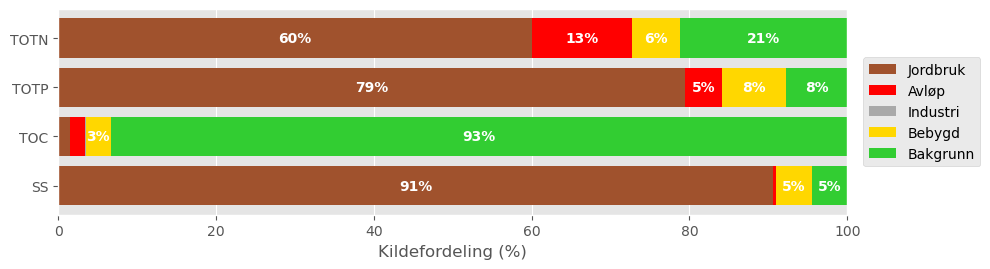

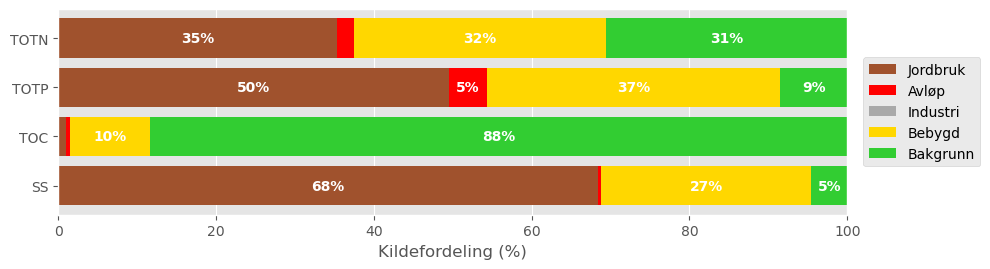

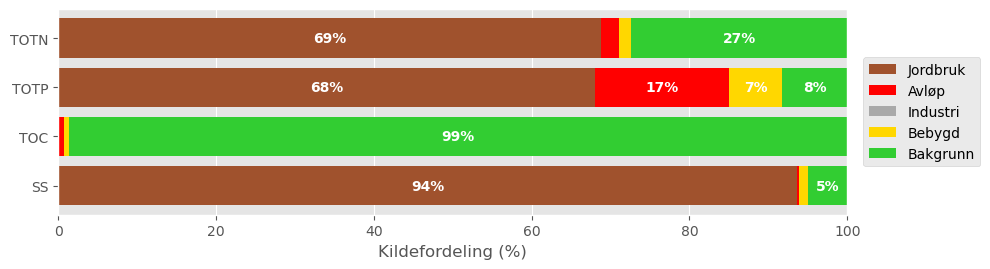

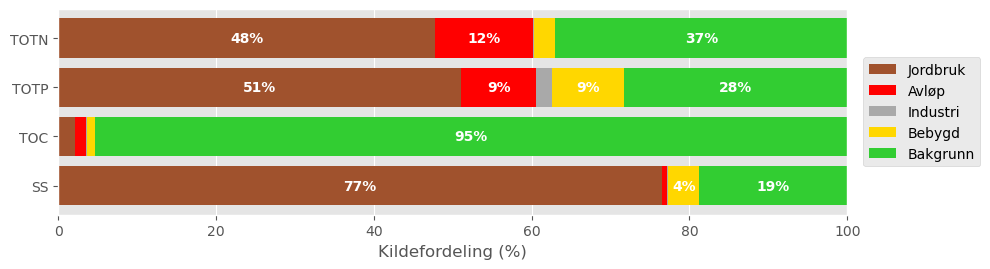

In [10]:
src_mod_df = mod_df.query("@src_st_yr <= `År` <= @src_end_yr").copy()
plot_order = ["TOTN", "TOTP", "TOC", "SS"]
if inc_sp_ov:
    col_dict = {
        # "Akvakultur": "royalblue",
        "Jordbruk": "sienna",
        "Avløp": "red",
        "Spredt": "black",
        "Overflow": "blue",
        "Industri": "darkgrey",
        "Bebygd": "gold",
        "Bakgrunn": "limegreen",
    }
else:
    col_dict = COLOUR_DICT
source_cols = list(col_dict.keys())
for stn_id, stn_df in src_mod_df.groupby("station_id"):
    name = stn_df.iloc[0]["catchment"]

    # Convert to percentages
    plot_df = stn_df.drop(columns="År").groupby("Parameter")[source_cols].sum()
    plot_df = 100 * plot_df.div(plot_df.sum(axis=1), axis=0)
    plot_df = plot_df.reindex(plot_order[::-1])

    # Plot
    fig, ax = plt.subplots(figsize=(10, 0.2 * len(plot_df) + 2))
    left = 0
    for source in source_cols:
        bars = ax.barh(
            plot_df.index,
            plot_df[source],
            left=left,
            color=COLOUR_DICT[source],
            label=source,
        )
        ax.bar_label(
            bars,
            labels=[f"{v:.0f}%" if v >= 3 else "" for v in plot_df[source]],
            label_type="center",
            color="white",
            fontsize=10,
            fontweight="bold",
        )
        left += plot_df[source]

    ax.set_xlim(0, 100)
    ax.set_xlabel("Kildefordeling (%)")
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
    )

    plt.tight_layout()

    # Save
    png_path = f"../plots/modelled/src_app_{name}_station_{stn_id}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")